In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_score, recall_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

In [2]:
fold_1_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_train.csv')
fold_2_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_train.csv')
fold_3_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_train.csv')
fold_4_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_train.csv')
fold_5_train = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_train.csv')

fold_1_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_1_val.csv')
fold_2_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_2_val.csv')
fold_3_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_3_val.csv')
fold_4_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_4_val.csv')
fold_5_val = pd.read_csv('/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv')

In [3]:
train_folds = [fold_1_train, fold_2_train, fold_3_train, fold_4_train, fold_5_train]
val_folds = [fold_1_val, fold_2_val, fold_3_val, fold_4_val, fold_5_val]

In [4]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

# Use fold 5 as validation
X_val = fold_5_val.drop(columns='fraud_bool') 
y_val = fold_5_val['fraud_bool']

In [5]:
# Step 2: Initialize the Naive Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)

# Step 3: Train the model on the training data
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [6]:
def evaluate_model(y_true, y_pred, y_proba=None, plot_pr_curve=True):
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Key Metrics
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\nPrecision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm.tolist()
    }

    # Probabilistic metrics
    if y_proba is not None:
        pr_auc = average_precision_score(y_true, y_proba)
        metrics['auc_pr'] = pr_auc
        print(f"AUC-PR (Average Precision): {pr_auc:.4f}")

        roc_auc = roc_auc_score(y_true, y_proba)
        metrics['roc_auc'] = roc_auc
        print(f"ROC AUC:                   {roc_auc:.4f}")

        if plot_pr_curve:
            precision_pts, recall_pts, _ = precision_recall_curve(y_true, y_proba)
            plt.figure(figsize=(6, 5))
            plt.plot(recall_pts, precision_pts, marker='.', label='PR Curve')
            plt.xlabel('Recall')
            plt.ylabel('Precision')
            plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    return metrics

In [7]:
# Step 4: Evaluate the model on the validation set
y_pred = rf.predict(X_val)
y_proba = rf.predict_proba(X_val)[:, 1]

Classification Report:
              precision    recall  f1-score   support

           0     0.9934    0.9519    0.9722    178711
           1     0.0835    0.4083    0.1387      1920

    accuracy                         0.9461    180631
   macro avg     0.5385    0.6801    0.5554    180631
weighted avg     0.9837    0.9461    0.9633    180631


Confusion Matrix:
[[170111   8600]
 [  1136    784]]

Precision: 0.0835
Recall:    0.4083
F1 Score:  0.1387
AUC-PR (Average Precision): 0.0891
ROC AUC:                   0.8546


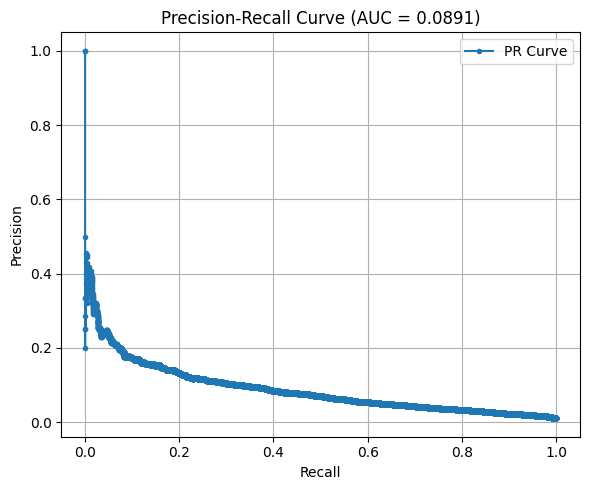

{'precision': 0.08354646206308611,
 'recall': 0.4083333333333333,
 'f1_score': 0.1387119603680113,
 'confusion_matrix': [[170111, 8600], [1136, 784]],
 'auc_pr': np.float64(0.08911421312759288),
 'roc_auc': np.float64(0.8545559692627576)}

In [8]:
evaluate_model(y_val, y_pred,y_proba)

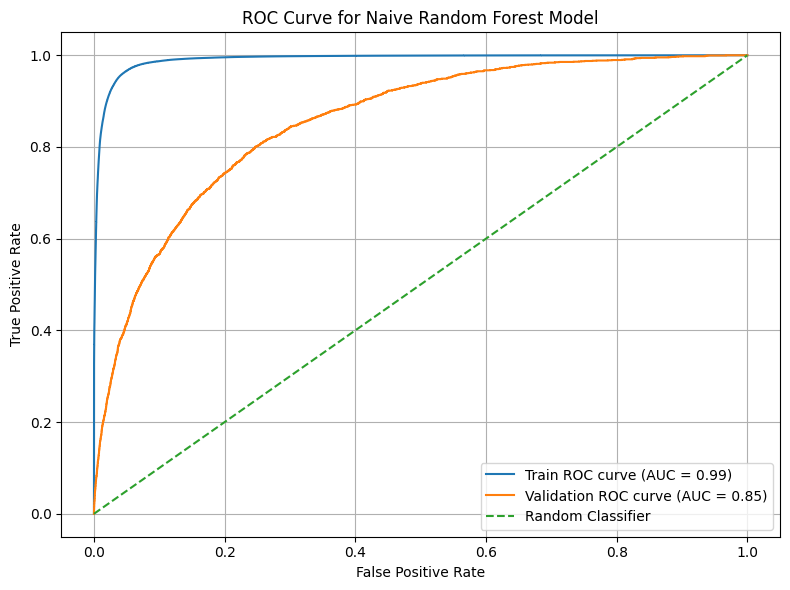

In [10]:
# Step 8: Plot ROC curve for the model's performance on Train vs. Test (Validation)
# Get the probabilities for the positive class (fraud)
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_val_proba = rf.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f'Train ROC curve (AUC = {roc_auc_score(y_train, y_train_proba):.2f})')
plt.plot(fpr_val, tpr_val, label=f'Validation ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Naive Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report 
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

## Feature Selection by Feature Importance from Naive Random Forest Model

In [14]:
# Initialize list to store selected features
selected_features_list = []

# Get feature importances from Naive Random Forest
feature_importances = rf.feature_importances_

# Create a DataFrame of feature names and their corresponding importance scores
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})

# Sort by importance
feature_df = feature_df.sort_values(by='Importance', ascending=False)

In [15]:
print(feature_df)

                             Feature    Importance
50                 device_os_windows  2.059291e-01
23                keep_alive_session  1.114381e-01
54              income_bin_Very High  8.926087e-02
15                  phone_home_valid  8.895453e-02
4                       customer_age  6.688431e-02
18                   has_other_cards  6.034584e-02
0                             income  5.031349e-02
3       current_address_months_count  4.866511e-02
33                   payment_type_AC  4.528135e-02
56         credit_risk_category_High  3.874061e-02
17                 bank_months_count  2.701470e-02
32                   payment_type_AB  2.246450e-02
29              total_address_months  1.775305e-02
19             proposed_credit_limit  1.492047e-02
13                 credit_risk_score  1.299245e-02
49                   device_os_other  1.180007e-02
55       credit_risk_category_Medium  1.137167e-02
53                   income_bin_High  1.066080e-02
1              name_email_simil

In [16]:
# Step 2: Calculate Cumulative Feature Importance
cumulative_importance = np.cumsum(feature_importances[feature_df.index])  # Cumulative sum of feature importances
total_importance = cumulative_importance[-1]  # Total importance (sum of all feature importances)

# Set a threshold for cumulative importance (e.g., 95%)
threshold = 0.95
best_num_features = np.where(cumulative_importance >= threshold * total_importance)[0][0] + 1  # Get index where cumulative importance exceeds threshold

# Select top N features based on cumulative importance
selected_features = feature_df['Feature'].head(best_num_features).values

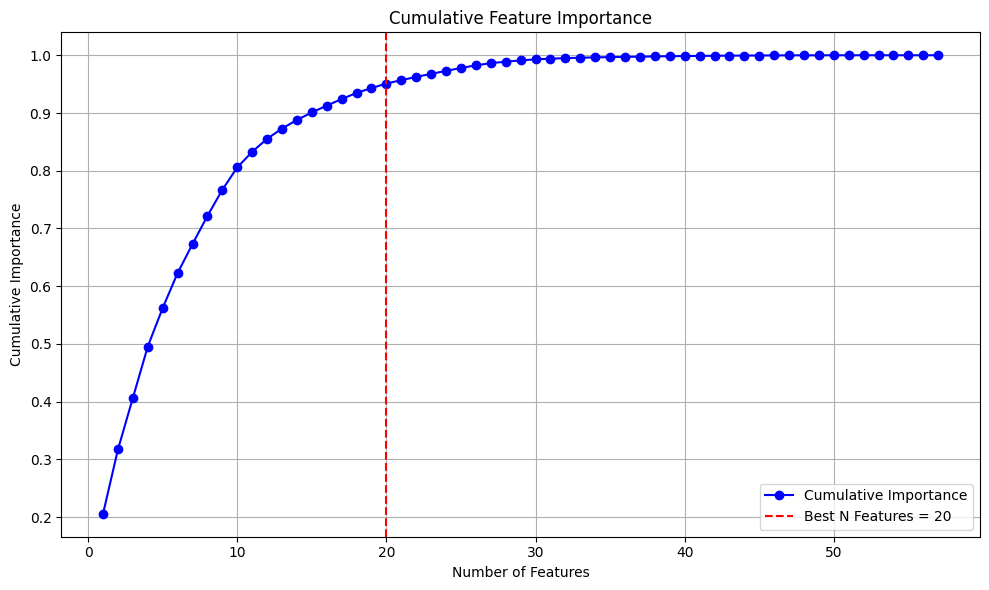

In [17]:
# Plot cumulative feature importance
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_importance) + 1), cumulative_importance, marker='o', color='blue', label='Cumulative Importance')
plt.axvline(x=best_num_features, color='red', linestyle='--', label=f'Best N Features = {best_num_features}')  # Add a vertical line for the best N features
plt.xlabel('Number of Features')
plt.ylabel('Cumulative Importance')
plt.title('Cumulative Feature Importance')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Trying RF Model Maximising AUC ROC

In [22]:
# Hyperparameter Tuning with Class Weights (using Optuna)
# Objective function for Optuna
def objective(trial):
    auc_roc = 0
    auc_pr = 0
    f1_score_avg = 0
    fold_classification_report = ""

    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 10, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced'])  # Class weight adjustment from None
    }

    # Loop through the 4 folds for training and tuning
    for i in range(4):  # Only use folds 1-4 for training and tuning
        # Load training data for the current fold
        fold_train_data = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_{i+1}_train.csv")
        
        # Separate features and target variable (using selected features)
        X_train_fold = fold_train_data[selected_features]  # Using only selected features
        y_train_fold = fold_train_data['fraud_bool']

        # Sample 10% of the current fold for hyperparameter tuning
        X_train_sampled = X_train_fold.sample(frac=0.1, random_state=42)  # Take 10% of the fold data
        y_train_sampled = y_train_fold[X_train_sampled.index]  # Corresponding labels for the sampled data

        # Create the Random Forest model with the suggested hyperparameters
        rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)

        # Fit the model with the sampled data (SMOTE was not applied here)
        rf.fit(X_train_sampled, y_train_sampled)

        # Predict and calculate the probabilities on the current fold
        y_pred_fold = rf.predict(X_train_fold)
        y_proba_fold = rf.predict_proba(X_train_fold)[:, 1]  # Get probability for the positive class (fraud)

        # Calculate the evaluation metrics
        auc_roc += roc_auc_score(y_train_fold, y_proba_fold)
        auc_pr += average_precision_score(y_train_fold, y_proba_fold)
        f1_score_avg += f1_score(y_train_fold, y_pred_fold)

        # Get classification report for the fold
        fold_classification_report += f"\nFold {i+1} Classification Report:\n"
        fold_classification_report += classification_report(y_train_fold, y_pred_fold)

    # Calculate the average AUC-ROC, AUC-PR, and F1-score across all folds
    auc_roc /= 4  # Average over folds 1-4
    auc_pr /= 4
    f1_score_avg /= 4

    # Return the AUC-ROC as the objective to maximize
    return auc_roc  # We are maximizing AUC-ROC

In [23]:
# Run Optuna for hyperparameter tuning
study = optuna.create_study(direction='maximize') 
study.optimize(objective, n_trials=20) 

# Print the best hyperparameters and AUC-ROC score
print(f"Best hyperparameters: {study.best_params}")
print(f"Best AUC-ROC: {study.best_value:.4f}")

[I 2025-04-15 01:12:33,501] A new study created in memory with name: no-name-3fe89bd7-065f-41c9-88cf-282524931e32
[I 2025-04-15 01:13:38,770] Trial 0 finished with value: 0.9930041740980113 and parameters: {'n_estimators': 69, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9930041740980113.
[I 2025-04-15 01:14:58,748] Trial 1 finished with value: 0.9948008362178892 and parameters: {'n_estimators': 103, 'max_depth': 14, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9948008362178892.
[I 2025-04-15 01:16:17,729] Trial 2 finished with value: 0.9941781979487407 and parameters: {'n_estimators': 80, 'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': 'balanced'}. Best is trial 1 with value: 0.9948008362178892.
[I 2025-04-15 01:17:28,892] Trial 3 finished with 

Best hyperparameters: {'n_estimators': 148, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'class_weight': 'balanced'}
Best AUC-ROC: 0.9959


In [24]:
# Fit the final model
best_params = study.best_params
rf_model_2 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [25]:
X_train_selected = X_train[selected_features]

# Fit the final model on the full training data (folds 1-4)
rf_model_2.fit(X_train_selected, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15,
                       max_features='log2', n_estimators=148, n_jobs=-1,
                       random_state=42)

In [27]:
# Load fold 5 data for final evaluation on fold 5 (unseen data)
fold_5_val = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv")
X_val = fold_5_val[selected_features] # Use selected features, no fraud bool col
y_val = fold_5_val['fraud_bool']

In [28]:
# Predict and evaluate on the test set (fold 5)
y_pred = rf_model_2.predict(X_val)
y_proba = rf_model_2.predict_proba(X_val)[:, 1]

Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9731    0.9828    178711
           1     0.1162    0.3297    0.1718      1920

    accuracy                         0.9662    180631
   macro avg     0.5544    0.6514    0.5773    180631
weighted avg     0.9833    0.9662    0.9741    180631


Confusion Matrix:
[[173896   4815]
 [  1287    633]]

Precision: 0.1162
Recall:    0.3297
F1 Score:  0.1718
AUC-PR (Average Precision): 0.1124
ROC AUC:                   0.9242


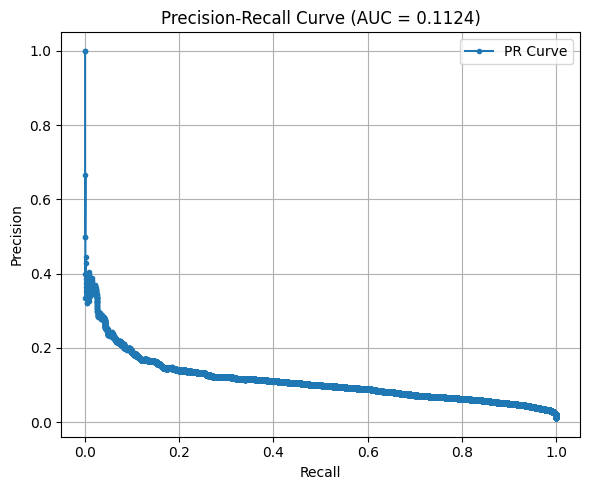

{'precision': 0.11618942731277533,
 'recall': 0.3296875,
 'f1_score': 0.17182410423452768,
 'confusion_matrix': [[173896, 4815], [1287, 633]],
 'auc_pr': np.float64(0.11235436225194075),
 'roc_auc': np.float64(0.9242398530891587)}

In [29]:
evaluate_model(y_val, y_pred, y_proba)

## Trying RF Model

In [40]:
# Hyperparameter Tuning with Class Weights (using Optuna)
# Objective function for Optuna
def objective(trial):
    auc_roc = 0
    auc_pr = 0
    f1_score_avg = 0
    fold_classification_report = ""

    # Hyperparameters to tune
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 10, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', None])  # Class weight adjustment from None
    }

    # Loop through the 4 folds for training and tuning
    for i in range(4):  # Only use folds 1-4 for training and tuning
        # Load training data for the current fold
        fold_train_data = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_{i+1}_train.csv")
        
        # Separate features and target variable (using selected features)
        X_train_fold = fold_train_data[selected_features]  # Using only selected features
        y_train_fold = fold_train_data['fraud_bool']

        # Sample 10% of the current fold for hyperparameter tuning
        X_train_sampled = X_train_fold.sample(frac=0.1, random_state=42)  # Take 10% of the fold data
        y_train_sampled = y_train_fold[X_train_sampled.index]  # Corresponding labels for the sampled data

        # Create the Random Forest model with the suggested hyperparameters
        rf = RandomForestClassifier(**param, random_state=42, n_jobs=-1)

        # Fit the model with the sampled data (SMOTE was not applied here)
        rf.fit(X_train_sampled, y_train_sampled)

        # Predict and calculate the probabilities on the current fold
        y_pred_fold = rf.predict(X_train_fold)
        y_proba_fold = rf.predict_proba(X_train_fold)[:, 1]  # Get probability for the positive class (fraud)

        # Calculate the evaluation metrics
        auc_roc += roc_auc_score(y_train_fold, y_proba_fold)
        auc_pr += average_precision_score(y_train_fold, y_proba_fold)
        f1_score_avg += f1_score(y_train_fold, y_pred_fold)

        # Get classification report for the fold
        fold_classification_report += f"\nFold {i+1} Classification Report:\n"
        fold_classification_report += classification_report(y_train_fold, y_pred_fold)

    # Calculate the average AUC-ROC, AUC-PR, and F1-score across all folds
    auc_roc /= 4  # Average over folds 1-4
    auc_pr /= 4
    f1_score_avg /= 4

    # Return the AUC-ROC as the objective to maximize
    return auc_roc

In [41]:
# Run Optuna for hyperparameter tuning
study_model_3 = optuna.create_study(direction='maximize') 
study_model_3.optimize(objective, n_trials=20) 

# Print the best hyperparameters and f1 score
print(f"Best hyperparameters: {study_model_3.best_params}")
print(f"Best AUC ROC: {study_model_3.best_value:.4f}")

[I 2025-04-15 21:27:13,532] A new study created in memory with name: no-name-f4c3f71d-5701-469b-9da3-9e2f58598257
[I 2025-04-15 21:28:19,784] Trial 0 finished with value: 0.9921844422998098 and parameters: {'n_estimators': 87, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'class_weight': None}. Best is trial 0 with value: 0.9921844422998098.
[I 2025-04-15 21:29:12,545] Trial 1 finished with value: 0.9904228704411708 and parameters: {'n_estimators': 59, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.9921844422998098.
[I 2025-04-15 21:30:05,430] Trial 2 finished with value: 0.9903459720063909 and parameters: {'n_estimators': 54, 'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 'log2', 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9921844422998098.
[I 2025-04-15 21:31:21,656] Trial 3 finished with value: 0.99189

Best hyperparameters: {'n_estimators': 130, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'class_weight': None}
Best AUC ROC: 0.9959


In [42]:
# Fit the final model
best_params = study_model_3.best_params
rf_model_3 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [43]:
# Concatenate SMOTEd folds 1-4 for training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

X_train_selected = X_train[selected_features]

# Fit the final model on the full training data (folds 1-4)
rf_model_3.fit(X_train_selected, y_train)

RandomForestClassifier(max_depth=15, n_estimators=130, n_jobs=-1,
                       random_state=42)

In [44]:
# Predict and evaluate on the test set (fold 5)
y_pred_model_3 = rf_model_3.predict(X_val)
y_proba_model_3 = rf_model_3.predict_proba(X_val)[:, 1]

Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9731    0.9828    178711
           1     0.1169    0.3312    0.1728      1920

    accuracy                         0.9663    180631
   macro avg     0.5548    0.6522    0.5778    180631
weighted avg     0.9834    0.9663    0.9742    180631


Confusion Matrix:
[[173906   4805]
 [  1284    636]]

Precision: 0.1169
Recall:    0.3312
F1 Score:  0.1728
AUC-PR (Average Precision): 0.1123
ROC AUC:                   0.9243


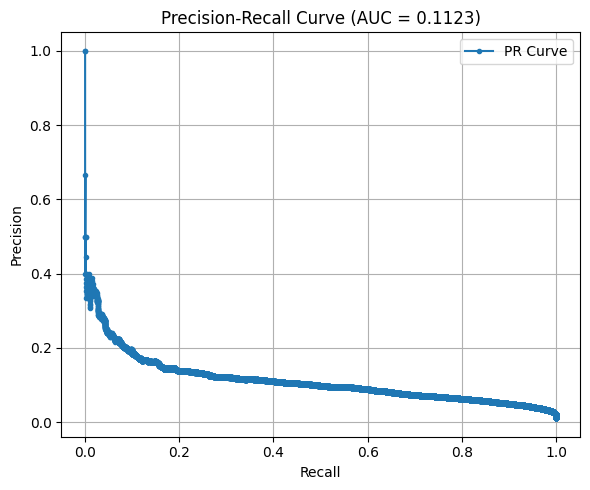

{'precision': 0.11689027752251424,
 'recall': 0.33125,
 'f1_score': 0.172802608341258,
 'confusion_matrix': [[173906, 4805], [1284, 636]],
 'auc_pr': np.float64(0.1123059139682511),
 'roc_auc': np.float64(0.9243383434007979)}

In [45]:
evaluate_model(y_val, y_pred_model_3, y_proba_model_3)

## Fitting with K Fold Cross Validation

In [46]:
# Use the best hyperparameters from Model 3 (Optuna Study)
best_params = study_model_3.best_params
rf_model_4 = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)

In [47]:
# Concatenate SMOTEd folds 1-4 for final training
training_data = pd.concat([fold_1_train, fold_2_train, fold_3_train, fold_4_train])
X_train = training_data.drop(columns='fraud_bool')
y_train = training_data['fraud_bool']

X_train_selected = X_train[selected_features]  

In [48]:
# Cross-validation setup (Stratified K-Fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_scores = []
auc_scores = []

In [49]:
# K-fold Cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_selected, y_train)):
    print(f"\n🟩 Fold {fold + 1}")

    # Split the data into training and validation sets for this fold
    X_train_fold, X_val_fold = X_train_selected.iloc[train_idx], X_train_selected.iloc[val_idx]
    y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # Fit the Random Forest model on the current fold's training data
    rf_model_4.fit(X_train_fold, y_train_fold)

    # Predict and calculate the probabilities on the validation set
    y_pred_fold = rf_model_4.predict(X_val_fold)
    y_proba_fold = rf_model_4.predict_proba(X_val_fold)[:, 1]  # Get probability for the positive class (fraud)

    # Calculate F1 score for this fold
    f1 = f1_score(y_val_fold, y_pred_fold)
    auc = roc_auc_score(y_val_fold, y_proba_fold)  # AUC-ROC

    # Append metrics for each fold
    f1_scores.append(f1)
    auc_scores.append(auc)

    # Print fold performance
    print(f"Fold {fold + 1} - F1: {f1:.4f}, AUC: {auc:.4f}")
    print(confusion_matrix(y_val_fold, y_pred_fold))
    print(classification_report(y_val_fold, y_pred_fold, digits=4))

# Final evaluations across all folds
print("\n✅ Cross-validation complete.")
print(f"Average F1 Score: {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"Average AUC Score: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")


🟩 Fold 1
Fold 1 - F1: 0.9754, AUC: 0.9968
[[556018  15858]
 [ 12309 559567]]
              precision    recall  f1-score   support

           0     0.9783    0.9723    0.9753    571876
           1     0.9724    0.9785    0.9754    571876

    accuracy                         0.9754   1143752
   macro avg     0.9754    0.9754    0.9754   1143752
weighted avg     0.9754    0.9754    0.9754   1143752


🟩 Fold 2
Fold 2 - F1: 0.9760, AUC: 0.9969
[[556304  15572]
 [ 11994 559882]]
              precision    recall  f1-score   support

           0     0.9789    0.9728    0.9758    571876
           1     0.9729    0.9790    0.9760    571876

    accuracy                         0.9759   1143752
   macro avg     0.9759    0.9759    0.9759   1143752
weighted avg     0.9759    0.9759    0.9759   1143752


🟩 Fold 3
Fold 3 - F1: 0.9755, AUC: 0.9968
[[555979  15897]
 [ 12246 559630]]
              precision    recall  f1-score   support

           0     0.9784    0.9722    0.9753    571876
   

In [55]:
# Load fold 5 data for final evaluation on fold 5 (unseen data)
fold_5_val = pd.read_csv(f"/Users/joanwong/Desktop/dsa4263/DSA4263 Project/data/preprocessed/fold_5_val.csv")
X_val = fold_5_val[selected_features] # Use selected features, no fraud bool col
y_val = fold_5_val['fraud_bool']

In [56]:
y_pred_model_4 = rf_model_4.predict(X_val)
y_proba_model_4 = rf_model_4.predict_proba(X_val)[:, 1]  # Probabilities for AUC-ROC

Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9735    0.9830    178711
           1     0.1204    0.3375    0.1775      1920

    accuracy                         0.9667    180631
   macro avg     0.5566    0.6555    0.5803    180631
weighted avg     0.9835    0.9667    0.9745    180631


Confusion Matrix:
[[173977   4734]
 [  1272    648]]

Precision: 0.1204
Recall:    0.3375
F1 Score:  0.1775
AUC-PR (Average Precision): 0.1128
ROC AUC:                   0.9249


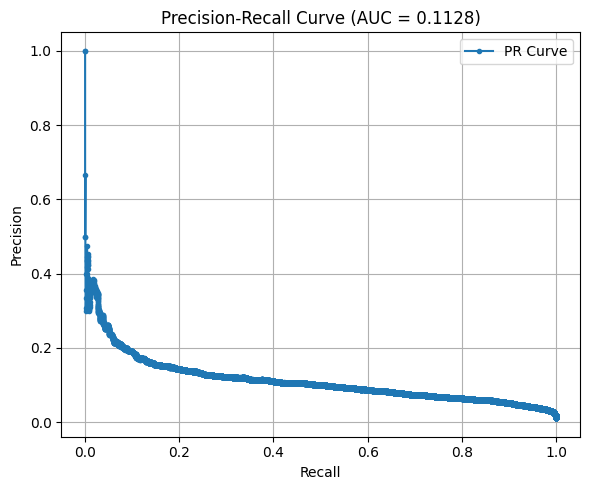

{'precision': 0.12040133779264214,
 'recall': 0.3375,
 'f1_score': 0.17748562037797863,
 'confusion_matrix': [[173977, 4734], [1272, 648]],
 'auc_pr': np.float64(0.11283138001001514),
 'roc_auc': np.float64(0.9248598004133302)}

In [57]:
evaluate_model(y_val, y_pred_model_4, y_proba_model_4)